# Derivation
## Potential energy
The Lennard-Jones potential energy equation is empirically motivated, the $r^{-12}$ term approximates electron cloud repulsion, while $r^{-6}$ represents attractive London Dispersion Forces. $\sigma$ and $\epsilon$ are fitted parameters, where $\sigma$ is the distance between two particles at which the potential energy is $0 \text{ J}$, and $\epsilon$ is the minimum value that the potential can reach.
$$U(r)=4\epsilon \left[\left(\frac{\sigma}{r}\right)^{12}-\left(\frac{\sigma}{r}\right)^6\right]$$
where $\text{r}$ - interparticle distance, $\sigma$ - length scale, $\epsilon$ - energy scale
## Force
$$F(r)=-\frac{dU}{dr}$$
$$F(r)=\epsilon\left[48\frac{\sigma^{12}}{r^{13}}-24\frac{\sigma^6}{r^7}\right]=\frac{24\epsilon}{r}\left[2\left(\frac{\sigma}{r}\right)^{12}-\left(\frac{\sigma}{r}\right)^6\right]$$
If $\text{F}>0$ - repulsion, if $\text{F}<0$ - attraction. 
# Reduced forms
## Potential energy
$$r^*=\frac{r}{\sigma}$$
$$U(r^*)=4\epsilon\left[\left(\frac{1}{r^*}\right)^{12}-\left(\frac{1}{r^*}\right)^6\right]$$
$$U^*=\frac{U}{\epsilon}$$
$$U^*(r^*)=4\left[\left(\frac{1}{r^*}\right)^{12}-\left(\frac{1}{r^*}\right)^6\right]$$
## Force
$$F^*(r^*)=-\frac{dU^*}{dr^*}=\frac{24}{r^*}\left[2\left(\frac{1}{r^*}\right)^{12}-\left(\frac{1}{r^*}\right)^6\right]$$


# Boundary conditions
Periodic boundary conditions: particles leaving one side of the box, reenter on the opposite side.
$$\Delta x_{ij}:=\Delta x_{ij}-L \times \text{round}\left(\frac{\Delta x_{ij}}{L}\right)$$
where $\Delta x_{ij}$ is the distance between two particles, and $\text{L}$ is the length of the box (in this case all in one dimension).

This ensures that the distance used in the calculations is always to the nearest periodic image of the particle, never the raw coordinate. To preserve the nearest periodic image, the size of the box should be at least two times the cutoff radius, otherwise the particle could interact with multiple images of the same neighbor simultaneously. Since minimum distance is at most at half the box length ($0.5 \times \text{L}$), and if $0.5 \times \text{L}$ falls within the cutoff radius ($0.5\times \text{L} \le \text{r}_{\text{cutoff}}$), then the particle could fall inside the cutoff radius of multiple images, causing the interaction to be calculated twice (at least in this case).

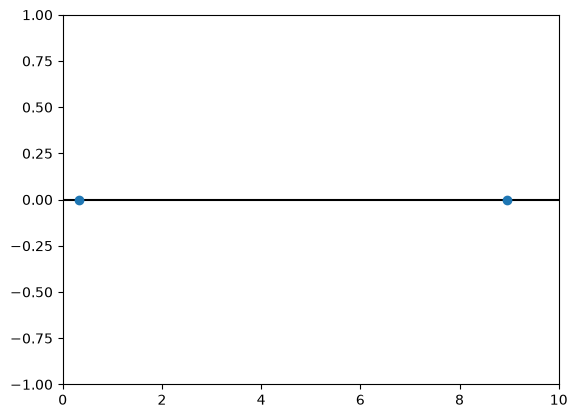

F* = -1.8480751644393023
r* = 1.370000000000001


In [ ]:
import random
import matplotlib.pyplot as plt
L=10
cutoff_radius=2.5
#Force calculation
i=round(random.uniform(0, L), 2)
j=round(random.uniform(0, L), 2)
x_ij=i-j
x_ij=x_ij-L*round(x_ij/L) #Applying the minimum image convention
r_star=abs(x_ij)
F_star=24/r_star*(2*(1/r_star)**12-(1/r_star)**6)
if r_star >=cutoff_radius:
    F_star=0 #Beyond the cutoff radius, the force is considered negligible and set to zero.
#Plotting
x=[i, j]
y=[0, 0]
plt.axhline(y=0, color='black', zorder=0)
plt.scatter(x, y, zorder=1)
plt.ylim(-1, 1)
plt.xlim(0, L)
plt.show()
print("F* = "+ str(F_star))
print("r* = "+ str(r_star))